# Classifier Baseline

Clean baseline pipeline for Random Forest earthquake classification with configurable threshold strategy on test metrics.

## 1) Setup

In [17]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists() and (candidate / 'config').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing src/ and config/.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config.config_loader import load_args_from_yaml
from src.data.preprocessing import load_and_filter_catalog
from src.data.utils import get_split_indices
from src.utils.file_utils import create_save_dir, save_args_to_json, save_or_load_data
from src.utils.metrics import classification_metrics

print(f'PROJECT_ROOT: {PROJECT_ROOT}')

PROJECT_ROOT: /root/autodl-tmp/chuandian_eq


## 2) Config

In [18]:
def load_rf_config(project_root: Path):
    args = load_args_from_yaml(str(project_root / 'config' / 'rf.yaml'))

    feature_cols = [
        'Num', 'Mag_max', 'Mag_mean', 'beta', 'b_lsq', 'a_lsq',
        'b_std_lsq', 'std_gr_lsq', 'b_mlk', 'a_mlk', 'b_std_mlk', 'std_gr_mlk',
        'dM_lsq', 'dM_mlk', 'Energy_sqrt', 'prob_x7_lsq', 'prob_x7_mlk',
        'zvalue',
    ] + [f'T_elaps{mag}' for mag in args.Mag_elaps]

    # Keep deterministic order while removing duplicates
    args.feature_cols = list(dict.fromkeys(feature_cols))
    args.dMag = 0.1

    args_dict = OmegaConf.to_container(args, resolve=True)
    args.save_dir = create_save_dir(
        str(project_root / 'checkpoints'),
        model_name='rf',
        args_dict=args_dict,
    )

    args_to_save = dict(args_dict)
    args_to_save.pop('save_dir', None)
    for key in [
        'model', 'batch_size', 'warmup_ratio', 'learning_rate', 'weight_decay',
        'scheduler_type', 'scheduler_factor', 'scheduler_patience', 'scheduler_threshold',
        'scheduler_min_lr', 'd_model', 'd_rnn', 'd_inner', 'n_layers', 'n_head', 'd_k',
        'd_v', 't_dropout', 'attn_type', 'mlp_out', 'mlp_dropout', 'mlp_hdw', 'epochs',
        'cuda_id',
    ]:
        args_to_save.pop(key, None)

    save_args_to_json(args_to_save, args.save_dir)
    return args


args = load_rf_config(PROJECT_ROOT)
BASE_DIR = PROJECT_ROOT / 'data' / args.dataset
print(f'Dataset: {args.dataset}')
print(f'Save dir: {args.save_dir}')

Dataset: ChuanDian
Save dir: /root/autodl-tmp/chuandian_eq/checkpoints/rf_fda2d0a6


## 3) Data Preparation

In [19]:
def print_sample_distribution(y: np.ndarray, dataset_name: str):
    positive_samples = int(np.sum(y == 1))
    negative_samples = int(np.sum(y == 0))
    total_samples = len(y)
    positive_ratio = positive_samples / total_samples if total_samples > 0 else 0.0
    negative_ratio = negative_samples / total_samples if total_samples > 0 else 0.0

    print(f'[{dataset_name}] positive: {positive_samples} | negative: {negative_samples} | total: {total_samples}')
    print(f'[{dataset_name}] positive ratio: {positive_ratio:.3f} | negative ratio: {negative_ratio:.3f}')


def prepare_data_rf(args, base_dir: Path):
    import src.features.seismic_features as sf
    from sklearn.preprocessing import MinMaxScaler

    df = load_and_filter_catalog(str(base_dir), Mc=args.Mc)

    def generate_data():
        features_df, num_mag = sf.calculate_seismic_features(
            df.to_numpy(),
            Mc=args.Mc,
            Mf=args.Mf,
            Twindow=args.Twindow,
            Tfore=args.Tfore,
            dt=args.dt,
            dMag=args.dMag,
            Mag_elaps=args.Mag_elaps,
            L_max=60,
            context_len=args.context_len,
        )
        return {'features_df': features_df, 'num_mag': num_mag}

    cached = save_or_load_data(
        base_path=str(base_dir),
        generate_fn=generate_data,
        sub_dir='processed/rf_classifier',
        prefix='rf',
        Mc=args.Mc,
        Mf=args.Mf,
        Twindow=args.Twindow,
        Tfore=args.Tfore,
        dt=args.dt,
        dMag=args.dMag,
        Mag_elaps=args.Mag_elaps,
        context_len=args.context_len,
    )

    features_df = cached['features_df']
    num_mag = cached['num_mag']

    missing_cols = [col for col in args.feature_cols if col not in features_df.columns]
    if missing_cols:
        raise KeyError(f'Missing feature columns: {missing_cols}')

    X = features_df[args.feature_cols].to_numpy()

    y = np.full(len(features_df), np.nan)
    y[features_df['shock_len'].values > 0] = 1
    y[features_df['Negative'].values == 1] = 0

    valid_mask = (y == 0) | (y == 1)
    X = X[valid_mask]
    y = y[valid_mask].astype(int)

    train_idx, val_idx, test_idx = get_split_indices(
        len(y),
        train_ratio=0.8,
        val_ratio=0.1,
        seed=0,
        by_time=args.split_by_time,
        time_order=args.time_order,
    )

    x_train_raw = X[train_idx]
    x_val_raw = X[val_idx]
    x_test_raw = X[test_idx]
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]

    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train_raw)
    x_val = scaler.transform(x_val_raw)
    x_test = scaler.transform(x_test_raw)

    print_sample_distribution(y_train, 'Train')
    print_sample_distribution(y_val, 'Validation')
    print_sample_distribution(y_test, 'Test')

    return df, features_df, x_train, x_val, x_test, y_train, y_val, y_test, num_mag


df, features_df, x_train, x_val, x_test, y_train, y_val, y_test, num_mag = prepare_data_rf(args, BASE_DIR)

print(f'features_df columns: {len(features_df.columns)}')
print(f"Mag_max mean: {features_df['Mag_max'].mean():.4f}")

CSV files found: ['Chuandian2021.csv']
[✔] Loading cached data from: /root/autodl-tmp/chuandian_eq/data/ChuanDian/processed/rf_classifier/rf_Mag_elaps_[5, 5.5, 6, 6.5]_Mc_3_Mf_5.5_Tfore_90_Twindow_180_context_len_1_dMag_0.1_dt_10.pkl
[Train] positive: 390 | negative: 830 | total: 1220
[Train] positive ratio: 0.320 | negative ratio: 0.680
[Validation] positive: 62 | negative: 90 | total: 152
[Validation] positive ratio: 0.408 | negative ratio: 0.592
[Test] positive: 19 | negative: 135 | total: 154
[Test] positive ratio: 0.123 | negative ratio: 0.877
features_df columns: 26
Mag_max mean: 5.4579


## 4) Train Random Forest

In [20]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
)
rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

## 5) ROC Curve

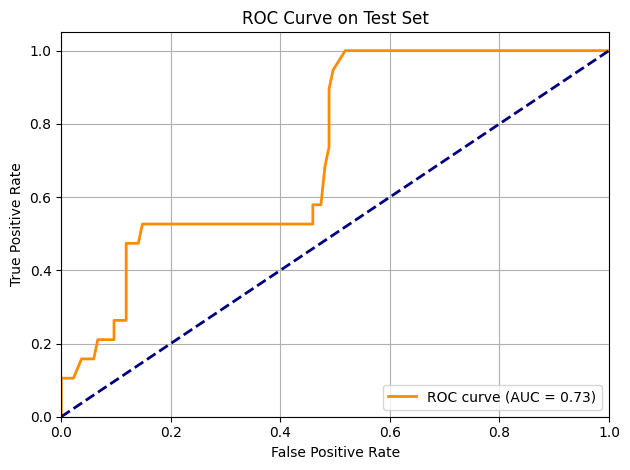

In [21]:
y_prob = rf.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(args.save_dir, 'roc_curve.png'))
plt.show()

## 6) Metrics With Threshold Switch

In [22]:
# For RF probabilities, keep apply_sigmoid=False.
# Supported modes:
# - 'auto'          : same as classification_metrics(y_test, y_prob)
# - 'val_threshold' : same as classification_metrics(y_test, y_prob, val_metrics['threshold'])
TEST_THRESHOLD_MODE = 'val_threshold'  # 'auto' | 'val_threshold'

y_val_prob = rf.predict_proba(x_val)[:, 1]
val_metrics = classification_metrics(y_val, y_val_prob, apply_sigmoid=False)

val_metrics_path = os.path.join(args.save_dir, 'val_metrics.json')
with open(val_metrics_path, 'w') as f:
    json.dump(val_metrics, f, indent=2)

if TEST_THRESHOLD_MODE == 'auto':
    # test_metrics = classification_metrics(y_test, y_prob)
    test_metrics = classification_metrics(y_test, y_prob, apply_sigmoid=False)
elif TEST_THRESHOLD_MODE == 'val_threshold':
    # test_metrics = classification_metrics(y_test, y_prob, val_metrics['threshold'])
    test_metrics = classification_metrics(
        y_test,
        y_prob,
        threshold=val_metrics['threshold'],
        apply_sigmoid=False,
    )
else:
    raise ValueError(f'Unknown TEST_THRESHOLD_MODE: {TEST_THRESHOLD_MODE}')

if 'recall' in test_metrics and 'precision' in test_metrics:
    test_metrics['R'] = test_metrics['recall'] * test_metrics['precision']

test_metrics['threshold_mode'] = TEST_THRESHOLD_MODE
test_metrics['val_threshold'] = float(val_metrics['threshold'])

test_metrics_path = os.path.join(args.save_dir, 'test_metrics.json')
with open(test_metrics_path, 'w') as f:
    json.dump(test_metrics, f, indent=2)

print('Validation metrics:')
print(val_metrics)
print()
print('Test metrics:')
print(test_metrics)

Validation metrics:
{'precision': 0.632183908045977, 'recall': 0.8870967741935484, 'f1': 0.738255033557047, 'auc': 0.8620967741935484, 'pr_auc': 0.8258700810325227, 'fpr': 0.35555555555555557, 'tpr': 0.8870967741935484, 'R': 0.5315412186379929, 'conf': 1.0, 'threshold': 0.2}

Test metrics:
{'precision': 0.14864864864864866, 'recall': 0.5789473684210527, 'f1': 0.23655913978494625, 'auc': 0.7276803118908383, 'pr_auc': 0.3311537529638216, 'fpr': 0.4666666666666667, 'tpr': 0.5789473684210527, 'R': 0.08605974395448081, 'conf': 0.9569056038423503, 'threshold': 0.2, 'threshold_mode': 'val_threshold', 'val_threshold': 0.2}


In [23]:
test_metrics

{'precision': 0.14864864864864866,
 'recall': 0.5789473684210527,
 'f1': 0.23655913978494625,
 'auc': 0.7276803118908383,
 'pr_auc': 0.3311537529638216,
 'fpr': 0.4666666666666667,
 'tpr': 0.5789473684210527,
 'R': 0.08605974395448081,
 'conf': 0.9569056038423503,
 'threshold': 0.2,
 'threshold_mode': 'val_threshold',
 'val_threshold': 0.2}

## 7) Feature Importance

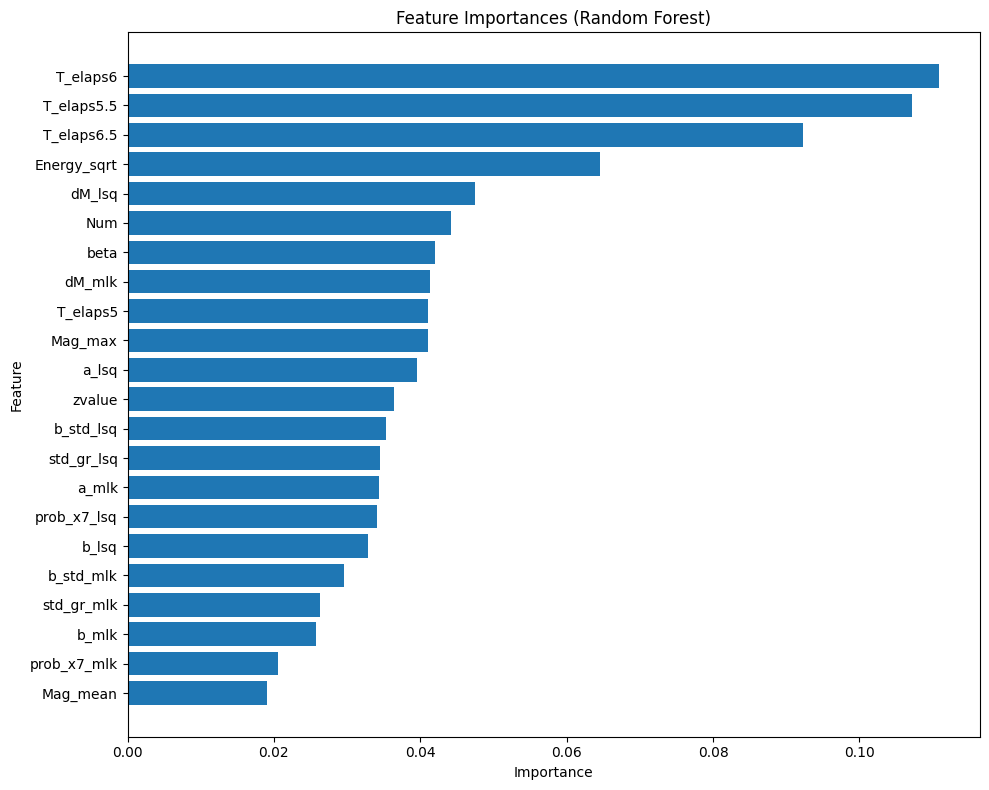

In [24]:
importances = rf.feature_importances_
feature_names = args.feature_cols

indices = np.argsort(importances)[::-1]
sorted_names = [feature_names[int(i)] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_importances)), sorted_importances, align='center')
plt.yticks(range(len(sorted_importances)), sorted_names)
plt.ylabel('Feature')
plt.xlabel('Importance')
plt.title('Feature Importances (Random Forest)')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig(os.path.join(args.save_dir, 'feature_importances.png'))
plt.show()